(51788, 43)
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/var/folders/l8/spvmzwbs7bs1x01lz_wgpmw40000gn/T/ipykernel_4609/1619891016.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy: 97.58%
Test Accuracy:  68.94%


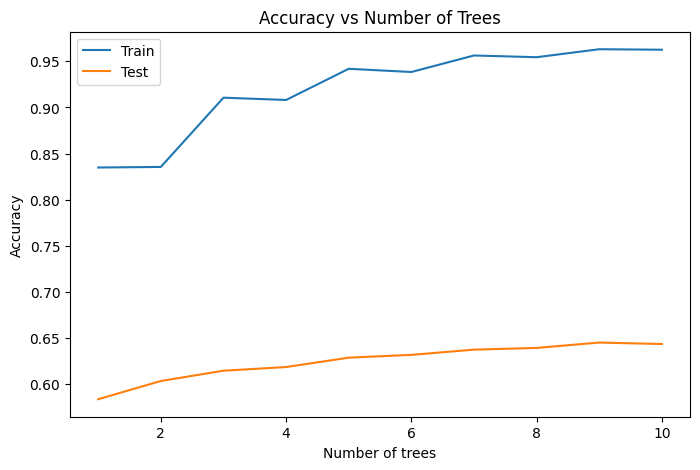

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

df = pd.read_csv("/Users/Akhil/vscode/Peptide/Data/ML_Ready/mhc_class_I.csv")
print(df.shape)
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


X = df.drop(columns=["is_cancer", "id"])
y = df["is_cancer"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=33)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth":    [5, 10, None],
    "min_samples_split": [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=33), param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
model = grid.best_estimator_

preds = model.predict(X_test)
train_preds = model.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train, train_preds):.2%}")
print(f"Test Accuracy:  {accuracy_score(y_test, preds):.2%}")


train_scores = []
test_scores = []
tree_range = range(1, 11, 1)

for n in tree_range:
    m = RandomForestClassifier(n_estimators=n, random_state=33)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(tree_range, train_scores, label="Train")
plt.plot(tree_range, test_scores, label="Test")
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.legend()
plt.show()

Top 20 most important features:


,feature,importance
0,Tissue,0.073171
2,molecular_weight,0.070680
4,hydrophobicity_GRAVY,0.065658
13,tcr_contact_hydro_mean,0.065651
12,boman_index,0.064622
7,instability_index,0.062908
3,charge_pH_7,0.058494
5,isoelectric_point,0.048441
11,aliphatic_index,0.041441
8,helix_fraction,0.030309


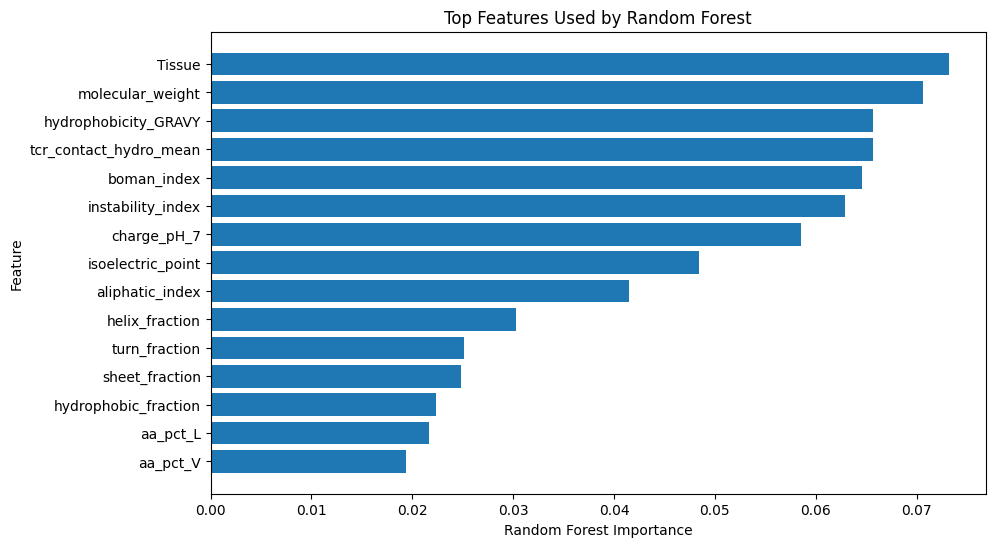

In [3]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 most important features:")
display(importance_df.head(20))

plt.figure(figsize=(10, 6))
top_features = importance_df.head(15).sort_values("importance")
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title("Top Features Used by Random Forest")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

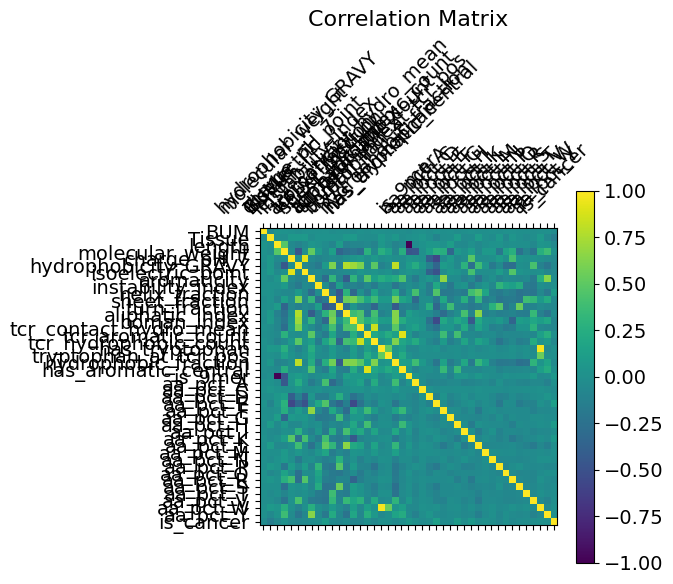

In [4]:
corr = df.corr()

# 2. Use matshow to display the matrix
plt.matshow(corr)

# 3. Optional: Add labels and colorbar
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)

In [7]:
df.head()

,id,Tissue,length,molecular_weight,charge_pH_7,hydrophobicity_GRAVY,isoelectric_point,aromaticity,instability_index,helix_fraction,...,aa_pct_N,aa_pct_P,aa_pct_Q,aa_pct_R,aa_pct_S,aa_pct_T,aa_pct_V,aa_pct_W,aa_pct_Y,is_cancer
0,0,7,9,1104.3455,2.757095,-0.344444,10.289686,0.111111,25.766667,0.444444,...,0.000000,0.000000,0.111111,0.111111,0.0,0.000000,0.222222,0.0,0.111111,0.0
1,1,7,9,1028.2032,-0.201325,0.577778,6.047009,0.000000,8.888889,0.555556,...,0.111111,0.000000,0.000000,0.111111,0.0,0.111111,0.111111,0.0,0.000000,0.0
2,2,8,9,884.1374,-0.499645,1.833333,5.275022,0.000000,20.855556,0.666667,...,0.000000,0.111111,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0
3,3,7,9,993.0680,-2.235967,0.388889,4.050028,0.111111,11.422222,0.444444,...,0.111111,0.000000,0.000000,0.000000,0.0,0.111111,0.000000,0.0,0.000000,1.0
4,4,7,10,1142.3423,-2.232466,0.600000,4.252659,0.000000,90.890000,0.600000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.100000,0.0,0.000000,1.0


/var/folders/l8/spvmzwbs7bs1x01lz_wgpmw40000gn/T/ipykernel_10124/2154890778.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


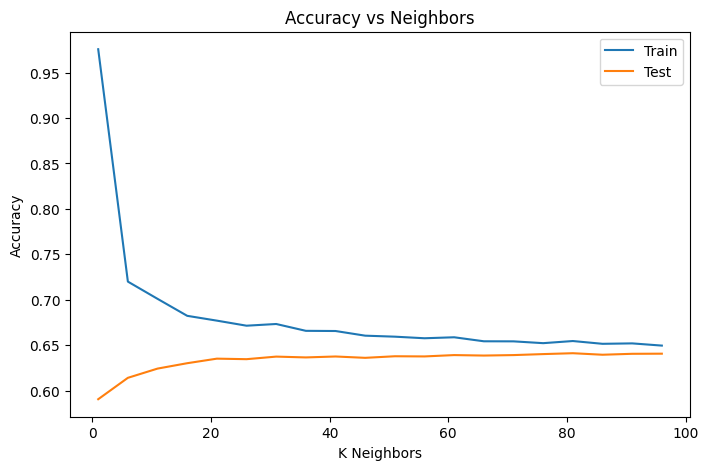

In [13]:
# K Nearest Neighbors (prob not going to work that well)
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("/Users/Akhil/vscode/Peptide/Data/ML_Ready/mhc_class_I.csv")

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop(columns=["is_cancer", "id"])
y = df["is_cancer"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_features = scaler.transform(X)
df_scaled = pd.DataFrame(scaled_features, columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size=0.3, random_state=33)

k_range = range(1, 101, 5)


train_scores = []
test_scores = []

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(k_range, train_scores, label="Train")
plt.plot(k_range, test_scores, label="Test")
plt.xlabel("K Neighbors")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Neighbors")
plt.legend()
plt.show()
    

In [19]:
# SVMs
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

df = pd.read_csv("/Users/Akhil/vscode/Peptide/Data/ML_Ready/mhc_class_I.csv")

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop(columns=["is_cancer", "id"])
y = df["is_cancer"]

param_grid = {'kernel': ['rbf', 'sigmoid'], 
            'C': [0.1, 1, 10, 100], 
            'gamma': ['scale', 'auto']}

model = GridSearchCV(SVC(), param_grid, verbose = 3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=33)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(confusion_matrix(y_test, predictions))
print('\n')
print(classification_report(y_test, predictions))

/var/folders/l8/spvmzwbs7bs1x01lz_wgpmw40000gn/T/ipykernel_10124/2304666429.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.551 total time=  24.1s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.551 total time=  24.0s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.551 total time=  23.4s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.551 total time=  23.5s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.551 total time=  23.6s
[CV 1/5] END C=0.1, gamma=scale, kernel=sigmoid;, score=0.499 total time=  15.5s
[CV 2/5] END C=0.1, gamma=scale, kernel=sigmoid;, score=0.498 total time=  15.6s
[CV 3/5] END C=0.1, gamma=scale, kernel=sigmoid;, score=0.495 total time=  15.5s
[CV 4/5] END C=0.1, gamma=scale, kernel=sigmoid;, score=0.493 total time=  15.6s
[CV 5/5] END C=0.1, gamma=scale, kernel=sigmoid;, score=0.500 total time=  15.5s
[CV 1/5] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.551 total time=  39.8s
[CV 2/5] END .....C=0.1, gamma=auto, kernel=rbf;

In [5]:
# code from graphein lib
from graphein.protein.config import ProteinGraphConfig
from graphein.protein.graphs import construct_graph

# Load the default config
path = "/Users/Akhil/vscode/Peptide/Data/peptide_structures/RYTTEFHEL.pdb"
c = ProteinGraphConfig(granularity='CA', pdb_dir=path)


# Construct the graph!
g = construct_graph(path = path)

Output()

In [6]:
from graphein.protein.visualisation import plotly_protein_structure_graph

plotly_protein_structure_graph(g, node_size_multiplier=0.5, colour_nodes_by="residue_name")

In [7]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import networkx as nx

# Get a list of nodes with their metadata attributes
node_list = list(g.nodes(data=True))

# Get a list of edges (u, v) with their metadata attributes
edge_list = list(g.edges(data=True))

import pandas as pd

# 1. Convert to an edge list
edge_data = []
for u, v, d in g.edges(data=True):
    edge_data.append({'source': u, 'target': v, **d})

edges_df = pd.DataFrame(edge_data)

# 2. Convert to a node list
node_data = []
for node, d in g.nodes(data=True):
    node_data.append({'node_id': node, **d})

nodes_df = pd.DataFrame(node_data)

[('A:ARG:1', 'A:TYR:2', {'kind': {'peptide_bond'}, 'distance': 3.8915383694426438}), ('A:TYR:2', 'A:THR:3', {'kind': {'peptide_bond'}, 'distance': 3.960214780265737}), ('A:THR:3', 'A:THR:4', {'kind': {'peptide_bond'}, 'distance': 3.9297589052717217}), ('A:THR:4', 'A:GLU:5', {'kind': {'peptide_bond'}, 'distance': 3.8371640710573587}), ('A:GLU:5', 'A:PHE:6', {'kind': {'peptide_bond'}, 'distance': 3.6783466272782124}), ('A:PHE:6', 'A:HIS:7', {'kind': {'peptide_bond'}, 'distance': 3.8600184511245312}), ('A:HIS:7', 'A:GLU:8', {'kind': {'peptide_bond'}, 'distance': 3.874228680437476}), ('A:GLU:8', 'A:LEU:9', {'kind': {'peptide_bond'}, 'distance': 3.8137308485312444})]


In [14]:
print(edges_df.head())


    source   target            kind  distance
0  A:ARG:1  A:TYR:2  {peptide_bond}  3.891538
1  A:TYR:2  A:THR:3  {peptide_bond}  3.960215
2  A:THR:3  A:THR:4  {peptide_bond}  3.929759
3  A:THR:4  A:GLU:5  {peptide_bond}  3.837164
4  A:GLU:5  A:PHE:6  {peptide_bond}  3.678347


In [17]:
# Assuming 'G' is your Graphein-generated NetworkX graph
global_attributes = g.graph

# Example: Extracting the protein's PDB identifier
pdb_id = global_attributes.get("pdb_id")
print("Global Context (PDB ID):", pdb_id)

# Extract all nodes and their features
all_nodes = g.nodes(data=True)

# Iterate through nodes to extract specific features
for node_id, node_features in all_nodes:
    residue_name = node_features.get("residue_name")
    coords = node_features.get("coords") # 3D spatial coordinates
    print(f"Node {node_id}: {residue_name} at {coords}")


# Extract all edges and their features
all_edges = g.edges(data=True)

# Iterate through edges to extract specific relationship data
for node_u, node_v, edge_features in all_edges:
    distance = edge_features.get("distance")
    bond_type = edge_features.get("kind") 
    print(f"Edge between {node_u} and {node_v} is of type {bond_type} (Distance: {distance})")

Global Context (PDB ID): None
Node A:ARG:1: ARG at [  6.204  -6.334 -15.353]
Node A:TYR:2: TYR at [  4.38   -4.27  -12.604]
Node A:THR:3: THR at [ 4.616 -6.251 -9.183]
Node A:THR:4: THR at [ 1.482 -5.656 -6.888]
Node A:GLU:5: GLU at [ 3.117 -5.527 -3.419]
Node A:PHE:6: PHE at [ 0.512 -6.23  -0.919]
Node A:HIS:7: HIS at [ 0.65  -4.259  2.397]
Node A:GLU:8: GLU at [-1.208 -5.897  5.376]
Node A:LEU:9: LEU at [-2.675 -3.331  7.786]
Edge between A:ARG:1 and A:TYR:2 is of type {'peptide_bond'} (Distance: 3.8915383694426438)
Edge between A:TYR:2 and A:THR:3 is of type {'peptide_bond'} (Distance: 3.960214780265737)
Edge between A:THR:3 and A:THR:4 is of type {'peptide_bond'} (Distance: 3.9297589052717217)
Edge between A:THR:4 and A:GLU:5 is of type {'peptide_bond'} (Distance: 3.8371640710573587)
Edge between A:GLU:5 and A:PHE:6 is of type {'peptide_bond'} (Distance: 3.6783466272782124)
Edge between A:PHE:6 and A:HIS:7 is of type {'peptide_bond'} (Distance: 3.8600184511245312)
Edge between A:HI